In [1]:
import random, math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, random_clifford, negativity, DensityMatrix, partial_trace
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
 
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [2]:
# Prepare a GHZ state

def GHZ_state(circuit, L):
    circuit.h(0)
    for qubit in range(1, L):
        circuit.cx(0, qubit)

# Depolarizing channel function

def random_depolarizing_channel(circuit, L):
    for i in range(L):
            depolarizingchannel = random_clifford(1, seed=None)
            circuit.unitary(depolarizingchannel, [i], label="dp")
        
# Clifford gate random brickwork circuit function

def random_brickwork_circuit(L):
    circuit = QuantumCircuit(L, L**2)

    GHZ_state(circuit, L)

    for t in range(L*2):
        circuit.save_density_matrix(label=f"dm_{t}")
        random_depolarizing_channel(circuit, L)
        if t % 2 == 0:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                circuit.unitary(gate, [2*i, 2*i+1], label=" ")
        else:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                if 2*i == L-2:
                    circuit.unitary(gate, [L-1, 0], label=" ")
                else:
                    circuit.unitary(gate, [2*i+1, 2*i+2], label=" ")

    # circuit.measure_all()
    return circuit

# Logarithmic Negativity Function

def calculate_log_negativity(dm, subsystem):
    rho = DensityMatrix(dm)
    negv = negativity(rho, subsystem)
    log_negv = math.log(2 * negv + 1, 2)
    return log_negv

# Create circuit

# random_brickwork_circuit(6).draw("mpl")

# Draw circuit

# circuit.draw("mpl")

In [3]:
# Number of Qubits and P Value Range

L = 8
p_values = np.arange(0, 1.05, 0.05)
time_steps = list(range(L * 2))

num_runs = 20
num_samples = len(time_steps) * num_runs

results = {}
results_std = {}

# Loop over all P Values for fixed Qubit number

for p in p_values:
    final_log_negv = []
    for i in range(num_runs):

        circuit = random_brickwork_circuit(L)
        depo_err_chan = depolarizing_error(round(1-p, 2), 1)

        # Noise model

        noise_model = NoiseModel()
        noise_model.add_basis_gates(['unitary'])
        noise_model.add_all_qubit_quantum_error(depo_err_chan, ["dp"])
        sim_noise = AerSimulator(noise_model=noise_model)

        # Job

        job = sim_noise.run(circuit)
        result = job.result().data()

        # Get Density Matrices

        log_negv_runs = []

        for t in time_steps:

            dm = result.get(f"dm_{t}")

            # Calculate negativity

            log_negv = calculate_log_negativity(dm, list(range(int(L/2))))
            log_negv_runs.append(log_negv)

        final_log_negv.append(log_negv_runs)

    results[p] = np.mean(final_log_negv, axis = 0)

# Plot results

plt.figure(figsize=(10, 6))

for p, avg_log_negv in results.items():
    plt.plot(time_steps, avg_log_negv, label=f"p = {p:.2f}", marker ="o")
    
plt.xlabel("Time Step")
plt.ylabel("Average Log Negativity")
plt.title("Log Negativity vs. Time Steps for Different Depolarization Probabilities")
plt.legend()
plt.grid()
plt.show()

KeyboardInterrupt: 

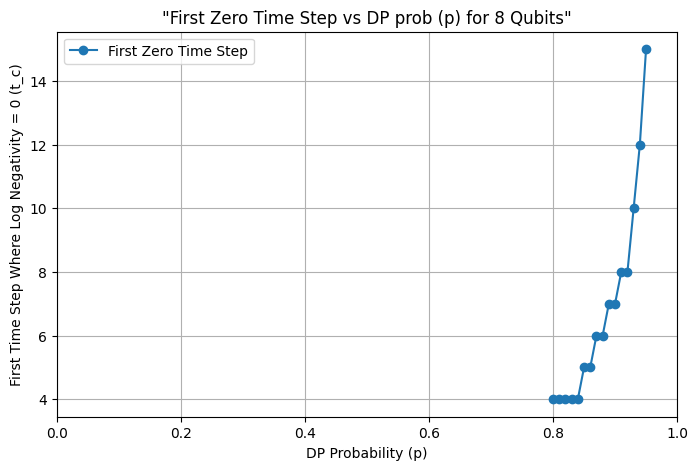

In [6]:
# Initialize all p values with None

first_zero_time_steps = {p: None for p in p_values}

# Find the first time step where the average log negativity drops close to zero, excluding the first time step

for p, avg_log_negv in results.items():
    first_zero_time_steps[p] = next(
        (t for t, val in enumerate(avg_log_negv[1:], start=1) if val <= 1e-6),  # Start from index 1
        None
    )
    # print(f"p = {p:.2f}, First Zero Time Step (excluding first step) = {first_zero_time_steps[p]}")

# Filter out None values

p_values_filtered = [p for p, t in first_zero_time_steps.items() if t is not None]
time_steps_filtered = [t for t in first_zero_time_steps.values() if t is not None]

# Plot

plt.figure(figsize=(8, 5))
plt.plot(
    p_values_filtered,
    time_steps_filtered,
    marker='o',
    label="First Zero Time Step"
)

# Ensure the x-axis starts at 0 and goes up to the maximum p value

plt.xlim(0, max(p_values))
plt.xlabel("DP Probability (p)")
plt.ylabel("First Time Step Where Log Negativity = 0 (t_c)")
plt.title(f'"First Zero Time Step vs DP prob (p) for {L} Qubits"')
plt.grid()
plt.legend()
plt.show()

/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/1519578187.py:4: RuntimeWarning: divide by zero encountered in log
  return -1 * (np.log(a)) / np.log(p) + c
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/1519578187.py:4: RuntimeWarning: divide by zero encountered in log
  return -1 * (np.log(a)) / np.log(p) + c
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/1519578187.py:4: RuntimeWarning: divide by zero encountered in log
  return -1 * (np.log(a)) / np.log(p) + c
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/1519578187.py:104: RuntimeWarning: divide by zero encountered in log
  p_fit_values.append(-1 * np.ceil((np.log(3)) / np.log(p)))
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/1519578187.py:104: RuntimeWarning: divide by zero encountered in scalar divide
  p_fit_values.append(-1 * np.ceil((np.log(3)) / np.log(p)))


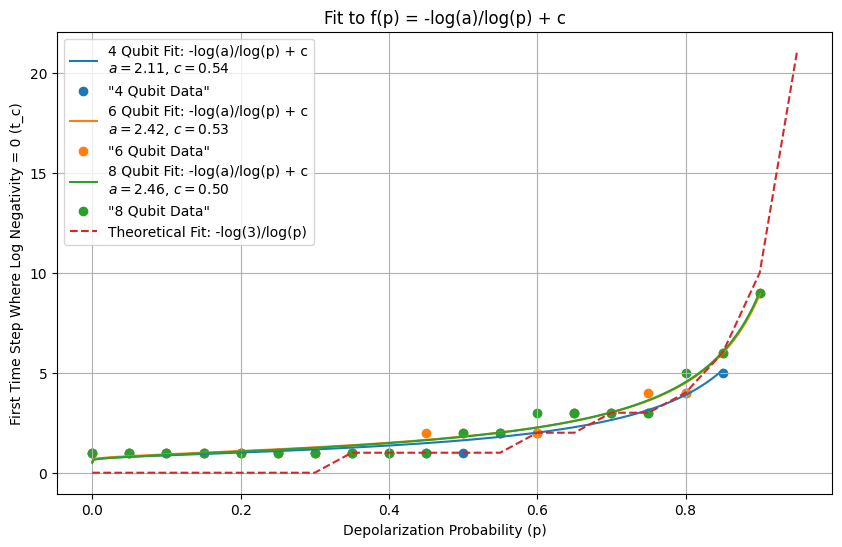

In [4]:
# Define Best Fit function f(p)

def model_function(p, a, c):
    return -1 * (np.log(a)) / np.log(p) + c

# Function to analyze negativity for a given number of qubits

def analyze_negativity_for_qubits(L, p_values, num_runs):
    time_steps = list(range(L * 2))
    results = {}
    first_zero_time_steps = {p: None for p in p_values}

    # Loop over all P values

    for p in p_values:
        final_log_negv = []
        for _ in range(num_runs):
            # Generate circuit and noise

            circuit = random_brickwork_circuit(L)
            depo_err_chan = depolarizing_error(round(1-p, 2), 1)

            # Noise model

            noise_model = NoiseModel()
            noise_model.add_basis_gates(['unitary'])
            noise_model.add_all_qubit_quantum_error(depo_err_chan, ["dp"])
            sim_noise = AerSimulator(noise_model=noise_model)

            # Job

            job = sim_noise.run(circuit)
            result = job.result().data()

            # Get density matrices and calculate negativity

            log_negv_runs = []
            for t in time_steps:
                dm = result.get(f"dm_{t}")
                log_negv = calculate_log_negativity(dm, list(range(int(L / 2))))
                log_negv_runs.append(log_negv)

            final_log_negv.append(log_negv_runs)

        # Average results

        results[p] = np.mean(final_log_negv, axis=0)

        # Find the first time step where negativity is zero

        first_zero_time_steps[p] = next(
            (t for t, val in enumerate(results[p][1:], start=1) if val <= 1e-6),
            None,
        )

    # Extract data for plotting

    p_values_filtered = [p for p, t in first_zero_time_steps.items() if t is not None]
    time_steps_filtered = [t for t in first_zero_time_steps.values() if t is not None]

    return p_values_filtered, time_steps_filtered

# Parameters

p_values = np.arange(0, 1.05, 0.05)
num_runs = 20
qubit_counts = [4, 6, 8]

# Plot results for each qubit count

plt.figure(figsize=(10, 6))

for L in qubit_counts:
    p_vals, t_steps = analyze_negativity_for_qubits(L, p_values, num_runs)

    # Filtered data

    p_values_filtered = np.array(p_vals)
    time_steps_filtered = np.array(t_steps)

    # Fit model to data

    initial_guess = [1.0, 1.0]  # Initial guess for [a, c]
    params, covariance = curve_fit(model_function, p_values_filtered, time_steps_filtered, p0=initial_guess)

    # Extract fitted parameters
    a_fitted, c_fitted = params

    # Generate fitted curve
    
    p_fit = np.linspace(min(p_values_filtered), max(p_values_filtered), 500)  # Smooth p range
    f_fit = model_function(p_fit, a_fitted, c_fitted)  # Fitted function values

    # Plot data and fit

    plt.plot(p_fit, f_fit, label=f"{L} Qubit Fit: -log(a)/log(p) + c\n$a={a_fitted:.2f}$, $c={c_fitted:.2f}$")
    plt.scatter(p_values_filtered, time_steps_filtered, label=f'"{L} Qubit Data"', marker="o")

# Fit plot

p_fit_values = []

for p in p_values:
    p_fit_values.append(-1 * np.ceil((np.log(3)) / np.log(p)))

plt.plot(p_values, p_fit_values, label="Theoretical Fit: -log(3)/log(p)", linestyle="--")

# Formatting the plot

plt.xlabel("Depolarization Probability (p)")
plt.ylabel("First Time Step Where Log Negativity = 0 (t_c)")
plt.title("Fit to f(p) = -log(a)/log(p) + c")
plt.grid()
plt.legend()
plt.show()

/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3886050454.py:64: RuntimeWarning: divide by zero encountered in log
  theoretical_predictions = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3886050454.py:64: RuntimeWarning: divide by zero encountered in log
  theoretical_predictions = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3886050454.py:64: RuntimeWarning: divide by zero encountered in log
  theoretical_predictions = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]



Results for 4 qubits:
R-squared: 0.6226
RMSE: 0.7454
Reduced Chi-square: 0.3996
p-value: 0.9861
Mean normalized residual: 0.3663
Std of normalized residuals: 0.4931
True data variance: 1.4722

Results for 6 qubits:
R-squared: 0.7263
RMSE: 0.9459
Reduced Chi-square: 0.2889
p-value: 0.9985
Mean normalized residual: 0.2620
Std of normalized residuals: 0.4529
True data variance: 3.2687

Results for 8 qubits:
R-squared: 0.7679
RMSE: 1.6125
Reduced Chi-square: 0.2444
p-value: 0.9997
Mean normalized residual: 0.0598
Std of normalized residuals: 0.4781
True data variance: 11.2000


/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3886050454.py:89: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3886050454.py:89: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3886050454.py:89: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]


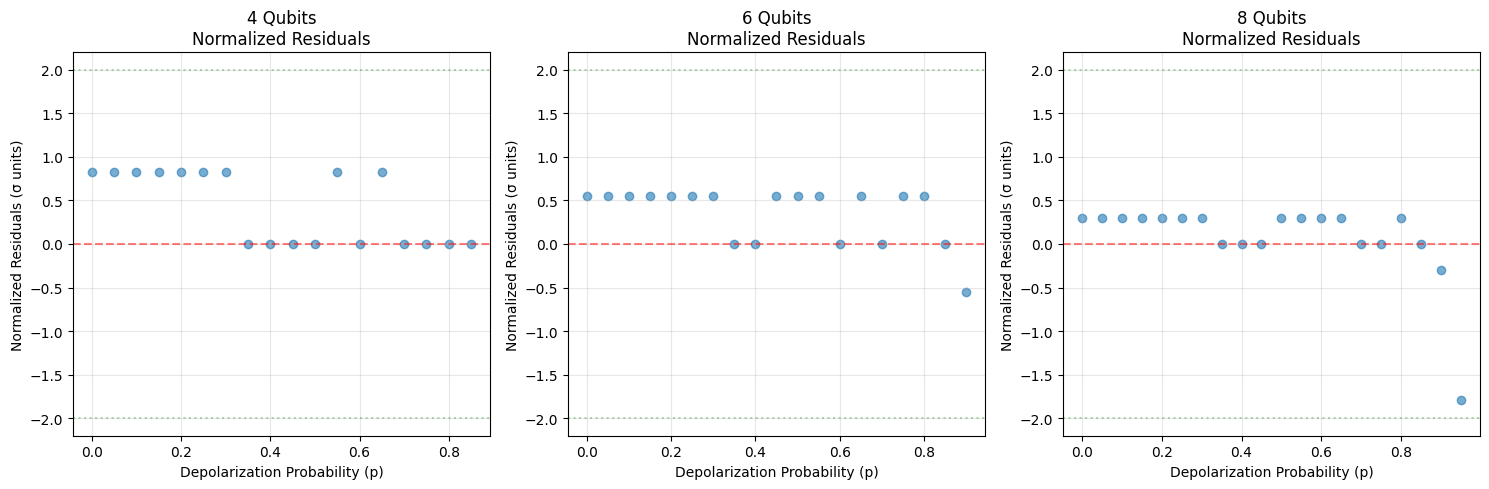

In [11]:
def statistical_analysis(L, p_values, time_steps, theoretical_fit):
    """
    Perform statistical analysis to compare experimental data with theoretical prediction
    with corrected chi-square calculation
    """
    # Remove any None values and align the arrays
    valid_indices = [i for i, t in enumerate(time_steps) if t is not None]
    exp_data = np.array([time_steps[i] for i in valid_indices])
    theo_data = np.array([theoretical_fit[i] for i in valid_indices])
    p_vals = np.array([p_values[i] for i in valid_indices])
    
    # Calculate R-squared
    ss_tot = np.sum((exp_data - np.mean(exp_data))**2)
    ss_res = np.sum((exp_data - theo_data)**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((exp_data - theo_data)**2))
    
    # Calculate true variance
    true_variance = np.var(exp_data)
    calc_variance = max(true_variance, 1e-10)  # Use small epsilon instead of 1.0

    # Calculate normalized chi-square statistic
    # Using variance of the experimental data as uncertainty
    # variance = np.var(exp_data)
    # if variance == 0:  # Handle case where variance is zero
    #     variance = 1.0
    
    # Calculate reduced chi-square (chi-square per degree of freedom)
    chi_square = np.sum((exp_data - theo_data)**2 / calc_variance)
    dof = len(exp_data) - 1  # degrees of freedom
    reduced_chi_square = chi_square / dof
    
    # Calculate p-value using reduced chi-square
    from scipy.stats import chi2
    p_value = 1 - chi2.cdf(chi_square, dof)
    
    # Calculate residuals
    residuals = exp_data - theo_data
    
    # Calculate normalized residuals
    normalized_residuals = residuals / np.sqrt(calc_variance)
    
    return {
        'L': L,
        'R_squared': r_squared,
        'RMSE': rmse,
        'chi_square': reduced_chi_square,  # Now reporting reduced chi-square
        'p_value': p_value,
        'mean_residual': np.mean(normalized_residuals),  # Now normalized
        'std_residual': np.std(normalized_residuals),    # Now normalized
        'true_variance': true_variance, # Report actual variance
        'variance': calc_variance # Report calculated variance
    }

# Perform analysis for each qubit count
results = []
for L in qubit_counts:
    # Get experimental data
    p_vals, t_steps = analyze_negativity_for_qubits(L, p_values, num_runs)
    
    # Calculate theoretical predictions
    theoretical_predictions = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
    
    # Perform statistical analysis
    stats = statistical_analysis(L, p_vals, t_steps, theoretical_predictions)
    results.append(stats)

# Print results with more detailed information
for result in results:
    print(f"\nResults for {result['L']} qubits:")
    print(f"R-squared: {result['R_squared']:.4f}")
    print(f"RMSE: {result['RMSE']:.4f}")
    print(f"Reduced Chi-square: {result['chi_square']:.4f}")
    print(f"p-value: {result['p_value']:.4f}")
    print(f"Mean normalized residual: {result['mean_residual']:.4f}")
    print(f"Std of normalized residuals: {result['std_residual']:.4f}")
    print(f"True data variance: {result['true_variance']:.4f}")
    if result['true_variance'] == 0:
        print("WARNING: Zero variance detected in data!")
        print(f"Using minimum variance of {result['variance_used']:.10f} for calculations")

# Visualize normalized residuals
plt.figure(figsize=(15, 5))
for i, result in enumerate(results):
    plt.subplot(1, len(results), i + 1)
    p_vals, t_steps = analyze_negativity_for_qubits(result['L'], p_values, num_runs)
    theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
    
    # Calculate normalized residuals
    residuals = np.array(t_steps) - np.array(theoretical)
    normalized_residuals = residuals / np.sqrt(result['variance'])
    
    plt.scatter(p_vals, normalized_residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=2, color='g', linestyle=':', alpha=0.3)  # 2σ line
    plt.axhline(y=-2, color='g', linestyle=':', alpha=0.3)  # -2σ line
    plt.title(f'{result["L"]} Qubits\nNormalized Residuals')
    plt.xlabel('Depolarization Probability (p)')
    plt.ylabel('Normalized Residuals (σ units)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_70679/4292016936.py:4: RuntimeWarning: divide by zero encountered in log
  return -1 * (np.log(a)) / np.log(p) + c


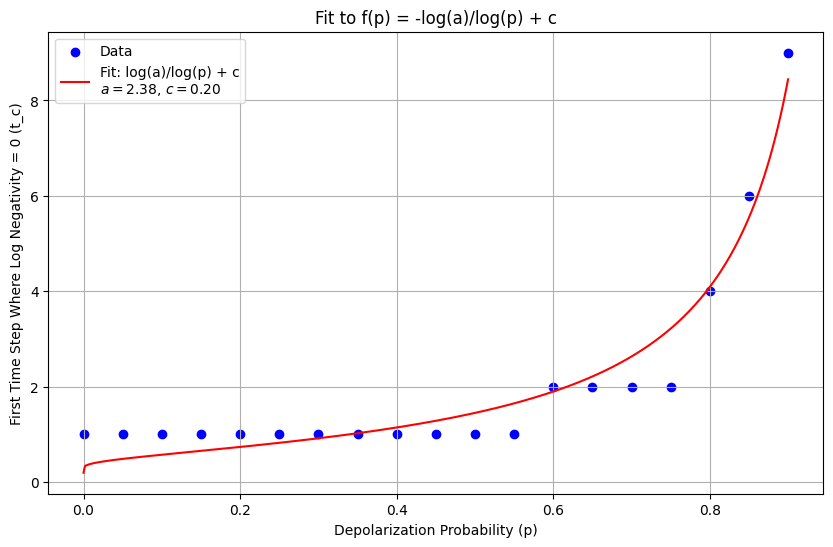

In [13]:
# # Define Best Fit function f(p)

# def model_function(p, a, c):
#     return -1 * (np.log(a)) / np.log(p) + c

# # Filtered data

# p_values_filtered = np.array(p_vals)
# time_steps_filtered = np.array(t_steps)

# # Fit model to data

# initial_guess = [1.0, 1.0]  # Initial guess for [a, c]
# params, covariance = curve_fit(model_function, p_values_filtered, time_steps_filtered, p0=initial_guess)

# # Extract fitted parameters
# a_fitted, c_fitted = params

# # Generate fitted curve
# p_fit = np.linspace(min(p_values_filtered), max(p_values_filtered), 500)  # Smooth p range
# f_fit = model_function(p_fit, a_fitted, c_fitted)  # Fitted function values

# # Plot data and fit
# plt.figure(figsize=(10, 6))
# plt.scatter(p_values_filtered, time_steps_filtered, label="Data", color="blue", marker="o")
# plt.plot(p_fit, f_fit, label=f"Fit: log(a)/log(p) + c\n$a={a_fitted:.2f}$, $c={c_fitted:.2f}$", color="red")
# plt.xlabel("Depolarization Probability (p)")
# plt.ylabel("First Time Step Where Log Negativity = 0 (t_c)")
# plt.title("Fit to f(p) = -log(a)/log(p) + c")
# plt.legend()
# plt.grid()
# plt.show()

/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3299728052.py:7: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3299728052.py:7: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3299728052.py:7: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3299728052.py:22: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/3299728052.py:22: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log

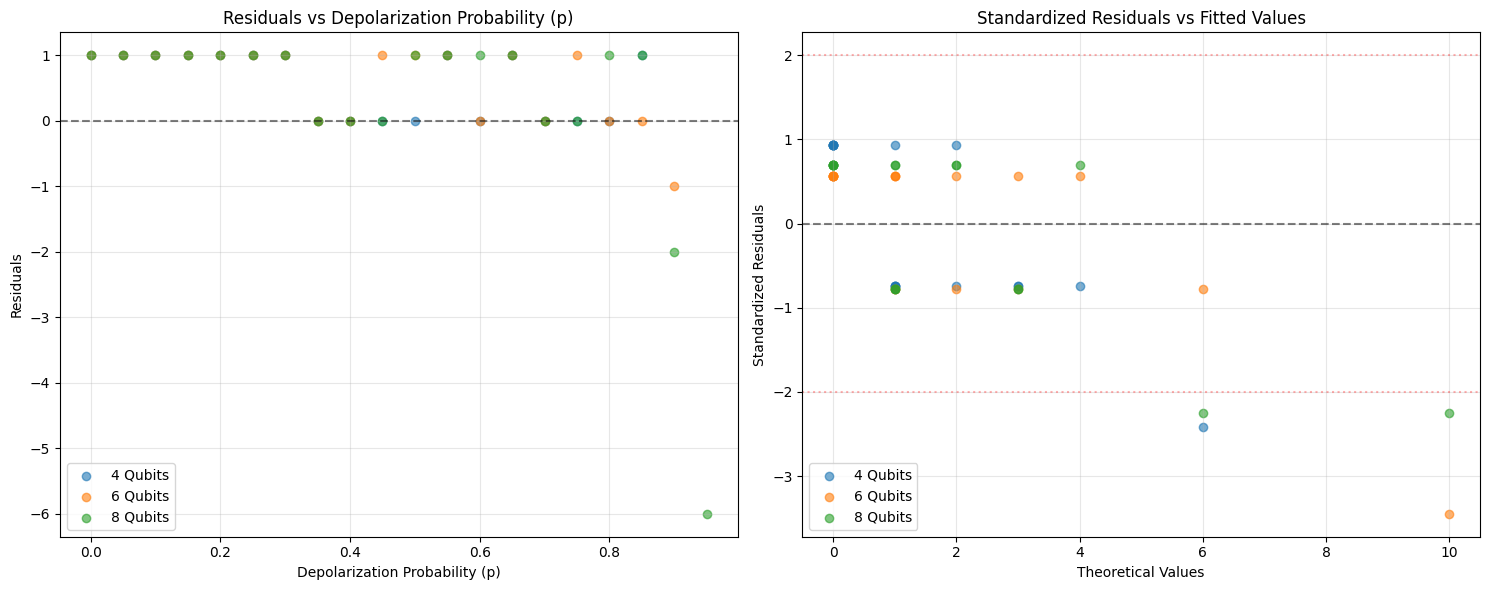

In [10]:
def plot_residuals(qubit_counts, p_values, num_runs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Residuals vs p-value
    for L in qubit_counts:
        p_vals, t_steps = analyze_negativity_for_qubits(L, p_values, num_runs)
        theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
        residuals = np.array(t_steps) - np.array(theoretical)
        
        ax1.scatter(p_vals, residuals, label=f'{L} Qubits', alpha=0.6)
        
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Depolarization Probability (p)')
    ax1.set_ylabel('Residuals')
    ax1.set_title('Residuals vs Depolarization Probability (p)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: Standardized Residuals
    for L in qubit_counts:
        p_vals, t_steps = analyze_negativity_for_qubits(L, p_values, num_runs)
        theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
        residuals = np.array(t_steps) - np.array(theoretical)
        
        # Standardize residuals
        std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
        ax2.scatter(theoretical, std_residuals, label=f'{L} Qubits', alpha=0.6)
        
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax2.axhline(y=2, color='r', linestyle=':', alpha=0.3)
    ax2.axhline(y=-2, color='r', linestyle=':', alpha=0.3)
    ax2.set_xlabel('Theoretical Values')
    ax2.set_ylabel('Standardized Residuals')
    ax2.set_title('Standardized Residuals vs Fitted Values')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_residuals(qubit_counts, p_values, num_runs)

In [ ]:
def enhanced_statistical_analysis(L, p_values, time_steps, theoretical_fit):
    """
    Enhanced statistical analysis with additional checks and diagnostics
    """
    from scipy import stats
    import seaborn as sns
    
    # Setup the figure for multiple plots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Basic Statistical Analysis
    valid_indices = [i for i, t in enumerate(time_steps) if t is not None]
    exp_data = np.array([time_steps[i] for i in valid_indices])
    theo_data = np.array([theoretical_fit[i] for i in valid_indices])
    p_vals = np.array([p_values[i] for i in valid_indices])
    
    # Calculate basic statistics
    variance = np.var(exp_data)
    if variance == 0:
        variance = 1.0
    residuals = exp_data - theo_data
    normalized_residuals = residuals / np.sqrt(variance)
    
    # Chi-square and p-value calculation
    chi_square = np.sum((exp_data - theo_data)**2 / variance)
    dof = len(exp_data) - 1
    reduced_chi_square = chi_square / dof
    p_value = 1 - stats.chi2.cdf(chi_square, dof)
    
    # 2. Error Analysis Plots
    
    # Plot 1: Basic Fit (top left)
    plt.subplot(3, 2, 1)
    plt.scatter(p_vals, exp_data, label='Experimental', alpha=0.6)
    plt.plot(p_vals, theo_data, 'r-', label='Theoretical', alpha=0.6)
    plt.xlabel('p value')
    plt.ylabel('Time Steps')
    plt.title(f'{L} Qubits: Data vs Theory')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Normalized Residuals vs p (top right)
    plt.subplot(3, 2, 2)
    plt.scatter(p_vals, normalized_residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=2, color='g', linestyle=':', alpha=0.3)
    plt.axhline(y=-2, color='g', linestyle=':', alpha=0.3)
    plt.xlabel('p value')
    plt.ylabel('Normalized Residuals')
    plt.title('Normalized Residuals vs p')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Q-Q Plot (middle left)
    plt.subplot(3, 2, 3)
    stats.probplot(normalized_residuals, dist="norm", plot=plt)
    plt.title('Q-Q Plot of Normalized Residuals')
    
    # Plot 4: Residuals Distribution (middle right)
    plt.subplot(3, 2, 4)
    sns.histplot(normalized_residuals, kde=True)
    plt.xlabel('Normalized Residuals')
    plt.ylabel('Count')
    plt.title('Distribution of Normalized Residuals')
    
    # Plot 5: Autocorrelation (bottom left)
    plt.subplot(3, 2, 5)
    from statsmodels.stats.diagnostic import acf
    acf_values = acf(normalized_residuals, nlags=len(normalized_residuals)//2)
    plt.plot(acf_values)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.axhline(y=2/np.sqrt(len(normalized_residuals)), color='g', linestyle=':')
    plt.axhline(y=-2/np.sqrt(len(normalized_residuals)), color='g', linestyle=':')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.title('Residuals Autocorrelation')
    
    # Plot 6: Scale-Location Plot (bottom right)
    plt.subplot(3, 2, 6)
    plt.scatter(theo_data, np.sqrt(np.abs(normalized_residuals)), alpha=0.6)
    plt.xlabel('Fitted Values')
    plt.ylabel('√|Standardized Residuals|')
    plt.title('Scale-Location Plot')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional Statistical Tests
    # Shapiro-Wilk test for normality
    shapiro_stat, shapiro_p = stats.shapiro(normalized_residuals)
    
    # Durbin-Watson test for autocorrelation
    from statsmodels.stats.stattools import durbin_watson
    dw_stat = durbin_watson(normalized_residuals)
    
    # Breusch-Pagan test for heteroscedasticity
    from statsmodels.stats.diagnostic import het_breuschpagan
    bp_stat, bp_p, _ = het_breuschpagan(normalized_residuals, theo_data.reshape(-1,1))
    
    results = {
        'L': L,
        'reduced_chi_square': reduced_chi_square,
        'p_value': p_value,
        'mean_residual': np.mean(normalized_residuals),
        'std_residual': np.std(normalized_residuals),
        'shapiro_stat': shapiro_stat,
        'shapiro_p': shapiro_p,
        'durbin_watson': dw_stat,
        'breusch_pagan_p': bp_p
    }
    
    # Print detailed analysis
    print(f"\nDetailed Analysis for {L} Qubits:")
    print(f"Reduced Chi-square: {reduced_chi_square:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Mean of normalized residuals: {np.mean(normalized_residuals):.4f}")
    print(f"Std of normalized residuals: {np.std(normalized_residuals):.4f}")
    print("\nNormality Test (Shapiro-Wilk):")
    print(f"Statistic: {shapiro_stat:.4f}")
    print(f"P-value: {shapiro_p:.4f}")
    print("Residuals are normal" if shapiro_p > 0.05 else "Residuals deviate from normality")
    print("\nAutocorrelation Test (Durbin-Watson):")
    print(f"Statistic: {dw_stat:.4f}")
    print("No autocorrelation" if 1.5 < dw_stat < 2.5 else "Possible autocorrelation")
    print("\nHeteroscedasticity Test (Breusch-Pagan):")
    print(f"P-value: {bp_p:.4f}")
    print("Homoscedastic" if bp_p > 0.05 else "Heteroscedastic")
    
    return results

# Run the enhanced analysis for each qubit count
enhanced_results = []
for L in qubit_counts:
    p_vals, t_steps = analyze_negativity_for_qubits(L, p_values, num_runs)
    theoretical_predictions = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
    results = enhanced_statistical_analysis(L, p_vals, t_steps, theoretical_predictions)
    enhanced_results.append(results)

/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_49748/287761944.py:135: RuntimeWarning: divide by zero encountered in log
  theoretical_predictions = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]


ModuleNotFoundError: No module named 'seaborn'

In [7]:
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'


Results for 4 qubits:

Log-transformed analysis:
R-squared: nan
P-value: nan
Slope: nan

Non-parametric analysis:
Spearman correlation: 0.8782
Spearman p-value: 0.0000
Kendall's Tau: 0.8330
Wilcoxon p-value: 0.0067


/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:67: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:14: RuntimeWarning: divide by zero encountered in log
  transformed_exp = exp_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:15: RuntimeWarning: divide by zero encountered in log
  transformed_theo = theo_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:15: RuntimeWarning: invalid value encountered in multiply
  transformed_theo = theo_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:23: RuntimeWarning: divide by zero encountered in log
  slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(p_vals), transformed_exp)
/opt/miniconda3/env

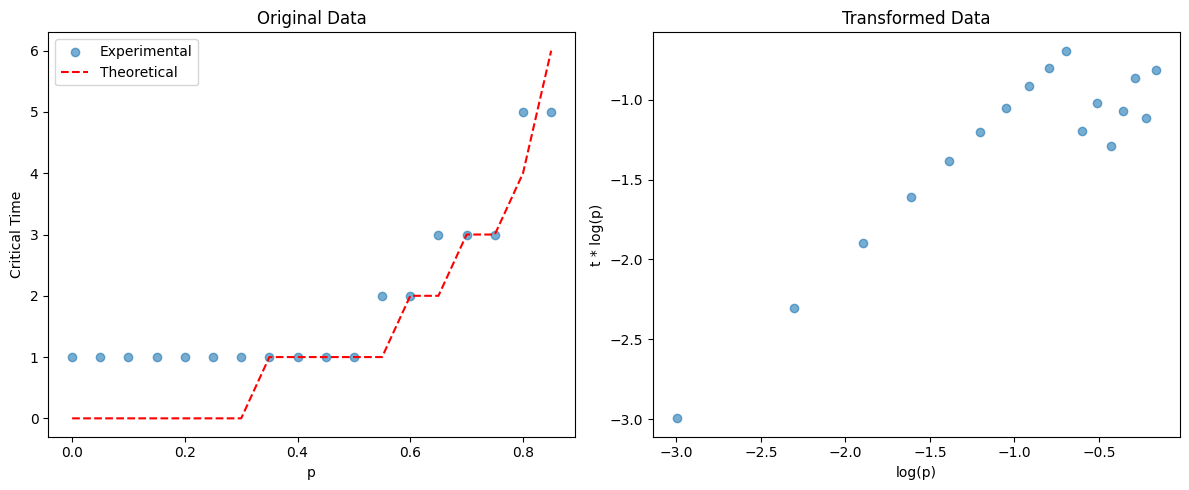


Results for 6 qubits:

Log-transformed analysis:
R-squared: nan
P-value: nan
Slope: nan

Non-parametric analysis:
Spearman correlation: 0.9327
Spearman p-value: 0.0000
Kendall's Tau: 0.9029
Wilcoxon p-value: 0.0076


/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:67: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:14: RuntimeWarning: divide by zero encountered in log
  transformed_exp = exp_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:15: RuntimeWarning: divide by zero encountered in log
  transformed_theo = theo_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:15: RuntimeWarning: invalid value encountered in multiply
  transformed_theo = theo_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:23: RuntimeWarning: divide by zero encountered in log
  slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(p_vals), transformed_exp)
/opt/miniconda3/env

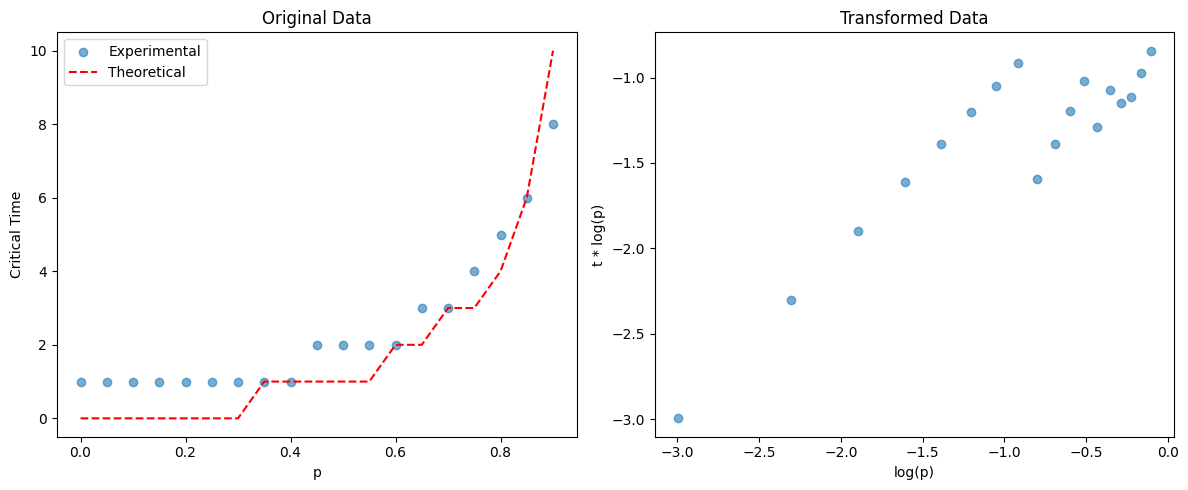


Results for 8 qubits:

Log-transformed analysis:
R-squared: nan
P-value: nan
Slope: nan

Non-parametric analysis:
Spearman correlation: 0.9172
Spearman p-value: 0.0000
Kendall's Tau: 0.8818
Wilcoxon p-value: 0.0076


/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:67: RuntimeWarning: divide by zero encountered in log
  theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:14: RuntimeWarning: divide by zero encountered in log
  transformed_exp = exp_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:15: RuntimeWarning: divide by zero encountered in log
  transformed_theo = theo_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:15: RuntimeWarning: invalid value encountered in multiply
  transformed_theo = theo_data * np.log(p_vals)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_55322/2823751948.py:23: RuntimeWarning: divide by zero encountered in log
  slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(p_vals), transformed_exp)
/opt/miniconda3/env

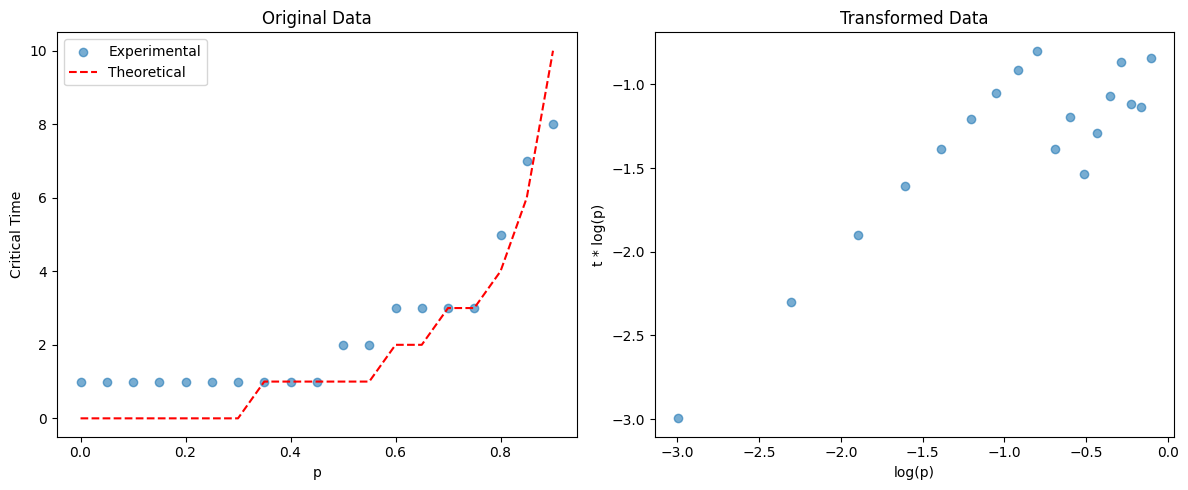

In [12]:
def log_transformed_analysis(L, p_values, time_steps, theoretical_fit):
    """
    Statistical analysis using log-transformed data to handle 1/log(p) relationship
    """
    # Remove None values and align arrays
    valid_indices = [i for i, t in enumerate(time_steps) if t is not None]
    exp_data = np.array([time_steps[i] for i in valid_indices])
    theo_data = np.array([theoretical_fit[i] for i in valid_indices])
    p_vals = np.array([p_values[i] for i in valid_indices])
    
    # Transform the data
    # We expect t = -log(a)/log(p) + c
    # So log(p)*t = -log(a) + c*log(p)
    transformed_exp = exp_data * np.log(p_vals)
    transformed_theo = theo_data * np.log(p_vals)
    
    # Calculate statistics on transformed data
    residuals = transformed_exp - transformed_theo
    variance = np.var(residuals)
    
    # Linear regression on transformed data
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(p_vals), transformed_exp)
    
    return {
        'L': L,
        'transformed_r_squared': r_value**2,
        'transformed_p_value': p_value,
        'slope': slope,
        'intercept': intercept,
        'std_err': std_err
    }

# 2. Non-parametric Tests
def non_parametric_analysis(L, p_values, time_steps, theoretical_fit):
    """
    Non-parametric statistical analysis for non-linear relationships
    """
    valid_indices = [i for i, t in enumerate(time_steps) if t is not None]
    exp_data = np.array([time_steps[i] for i in valid_indices])
    theo_data = np.array([theoretical_fit[i] for i in valid_indices])
    p_vals = np.array([p_values[i] for i in valid_indices])
    
    from scipy import stats
    
    # Spearman rank correlation
    spearman_corr, spearman_p = stats.spearmanr(exp_data, theo_data)
    
    # Kendall's Tau
    kendall_tau, kendall_p = stats.kendalltau(exp_data, theo_data)
    
    # Wilcoxon signed-rank test for paired samples
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(exp_data, theo_data)
    
    return {
        'L': L,
        'spearman_corr': spearman_corr,
        'spearman_p': spearman_p,
        'kendall_tau': kendall_tau,
        'kendall_p': kendall_p,
        'wilcoxon_p': wilcoxon_p
    }

# Run both analyses
for L in qubit_counts:
    p_vals, t_steps = analyze_negativity_for_qubits(L, p_values, num_runs)
    theoretical = [-1 * np.ceil((np.log(3)) / np.log(p)) for p in p_vals]
    
    # Log-transformed analysis
    log_results = log_transformed_analysis(L, p_vals, t_steps, theoretical)
    
    # Non-parametric analysis
    nonparam_results = non_parametric_analysis(L, p_vals, t_steps, theoretical)
    
    print(f"\nResults for {L} qubits:")
    print("\nLog-transformed analysis:")
    print(f"R-squared: {log_results['transformed_r_squared']:.4f}")
    print(f"P-value: {log_results['transformed_p_value']:.4f}")
    print(f"Slope: {log_results['slope']:.4f}")
    
    print("\nNon-parametric analysis:")
    print(f"Spearman correlation: {nonparam_results['spearman_corr']:.4f}")
    print(f"Spearman p-value: {nonparam_results['spearman_p']:.4f}")
    print(f"Kendall's Tau: {nonparam_results['kendall_tau']:.4f}")
    print(f"Wilcoxon p-value: {nonparam_results['wilcoxon_p']:.4f}")

    # Visualize the transformed data
    plt.figure(figsize=(12, 5))
    
    # Original data
    plt.subplot(1, 2, 1)
    plt.scatter(p_vals, t_steps, alpha=0.6, label='Experimental')
    plt.plot(p_vals, theoretical, 'r--', label='Theoretical')
    plt.xlabel('p')
    plt.ylabel('Critical Time')
    plt.title('Original Data')
    plt.legend()
    
    # Transformed data
    plt.subplot(1, 2, 2)
    plt.scatter(np.log(p_vals), np.array(t_steps) * np.log(p_vals), alpha=0.6)
    plt.xlabel('log(p)')
    plt.ylabel('t * log(p)')
    plt.title('Transformed Data')
    
    plt.tight_layout()
    plt.show()